In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/autogluon-1-4-0-wheels-akihiro/autogluon.tabular-1.4.0-py3-none-any.whl
/kaggle/input/autogluon-1-4-0-wheels-akihiro/autogluon.core-1.4.0-py3-none-any.whl
/kaggle/input/autogluon-1-4-0-wheels-akihiro/autogluon.features-1.4.0-py3-none-any.whl
/kaggle/input/autogluon-1-4-0-wheels-akihiro/autogluon.common-1.4.0-py3-none-any.whl
/kaggle/input/qwen2.5/transformers/0.5b/1/config.json
/kaggle/input/qwen2.5/transformers/0.5b/1/merges.txt
/kaggle/input/qwen2.5/transformers/0.5b/1/LICENSE
/kaggle/input/qwen2.5/transformers/0.5b/1/README.md
/kaggle/input/qwen2.5/transformers/0.5b/1/tokenizer.json
/kaggle/input/qwen2.5/transformers/0.5b/1/vocab.json
/kaggle/input/qwen2.5/transformers/0.5b/1/tokenizer_config.json
/kaggle/input/qwen2.5/transformers/0.5b/1/model.safetensors
/kaggle/input/qwen2.5/transformers/0.5b/1/.gitattributes
/kaggle/input/qwen2.5/transformers/0.5b/1/generation_config.json
/kaggle/input/playground-series-s5e9/sample_submission.csv
/kaggle/input/playground-series-s5e

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e9/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e9/test.csv')
train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [3]:
test.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


In [4]:
train.describe()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257586,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,524163.000000,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [6]:
test.describe()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
count,174722.000000,174722.000000,174722.000000,174722.000000,174722.000000,174722.000000,174722.000000,174722.000000,174722.000000,174722.000000
mean,611524.500000,0.632591,-8.377495,0.074475,0.262903,0.117407,0.178317,0.555861,241753.736419,0.500545
std,50438.041204,0.157229,4.622288,0.050024,0.222899,0.131628,0.118165,0.226218,59103.896616,0.290550
min,524164.000000,0.140859,-27.442731,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067
25%,567844.250000,0.514918,-11.550095,0.023500,0.069448,0.000001,0.077821,0.403788,207518.151300,0.253817
50%,611524.500000,0.634556,-8.253186,0.066432,0.242412,0.073968,0.165956,0.566015,243584.585400,0.511867
75%,655204.750000,0.739179,-4.903740,0.107302,0.396870,0.202977,0.268133,0.716694,281737.445300,0.746133
max,698885.000000,0.975000,-1.357000,0.258857,0.995000,0.680914,0.599544,0.978000,449288.808400,0.999867


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174722 entries, 0 to 174721
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         174722 non-null  int64  
 1   RhythmScore                174722 non-null  float64
 2   AudioLoudness              174722 non-null  float64
 3   VocalContent               174722 non-null  float64
 4   AcousticQuality            174722 non-null  float64
 5   InstrumentalScore          174722 non-null  float64
 6   LivePerformanceLikelihood  174722 non-null  float64
 7   MoodScore                  174722 non-null  float64
 8   TrackDurationMs            174722 non-null  float64
 9   Energy                     174722 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 13.3 MB


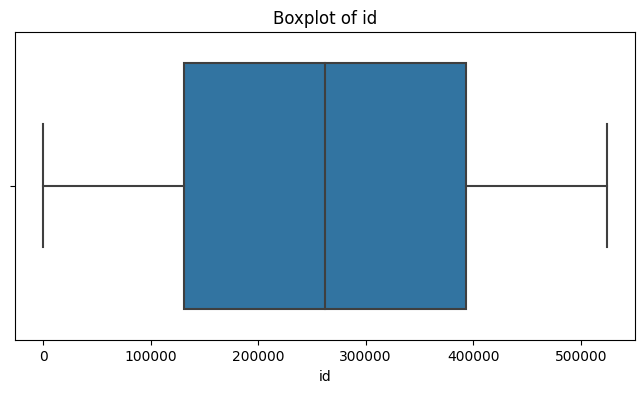

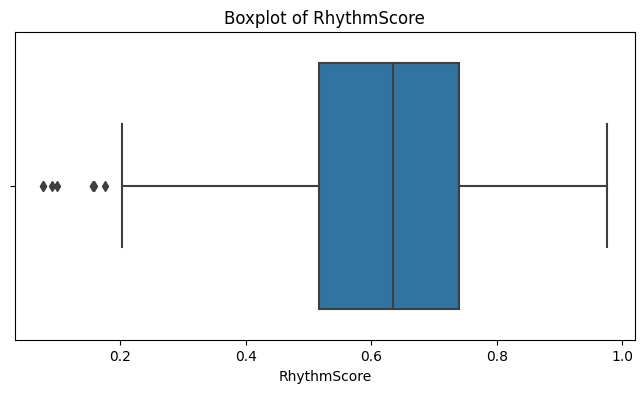

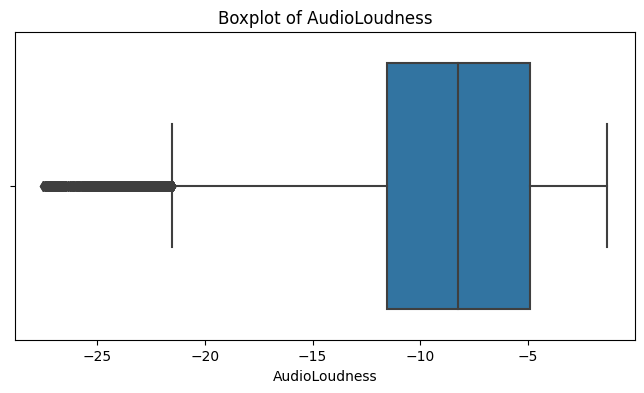

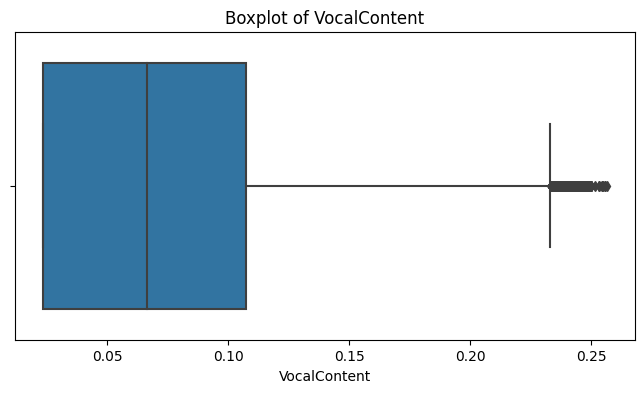

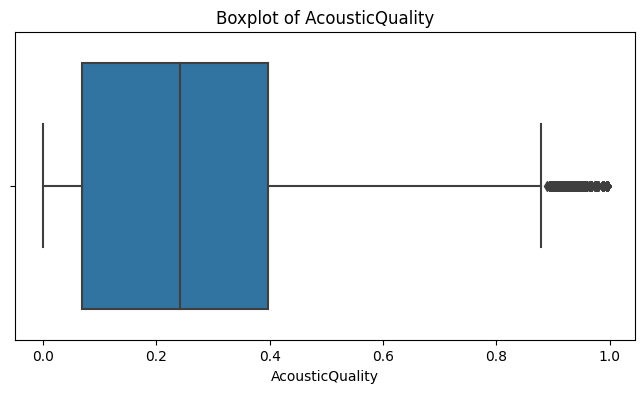

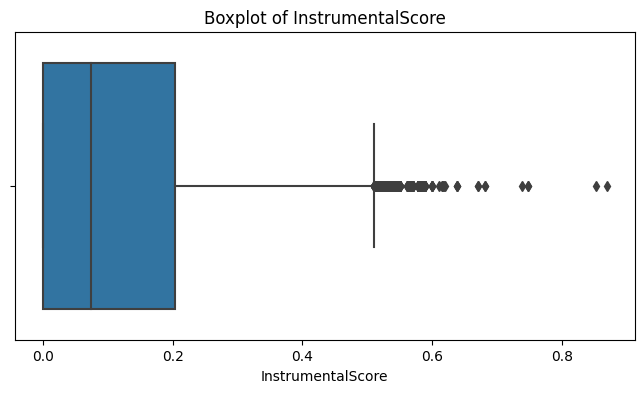

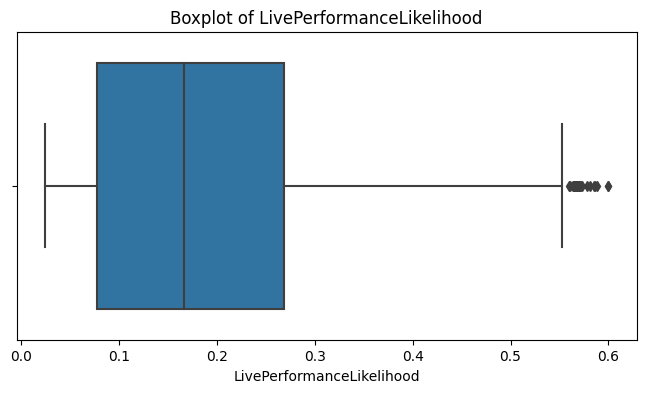

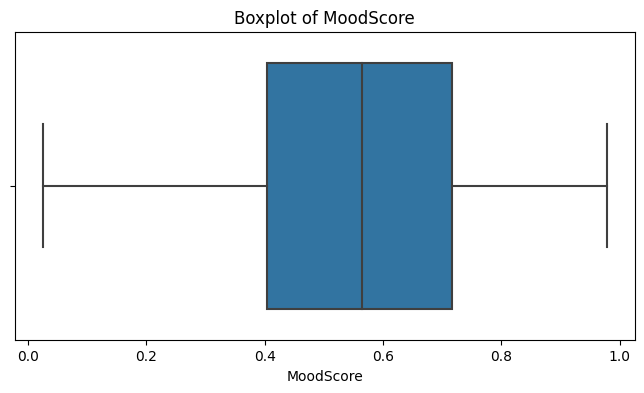

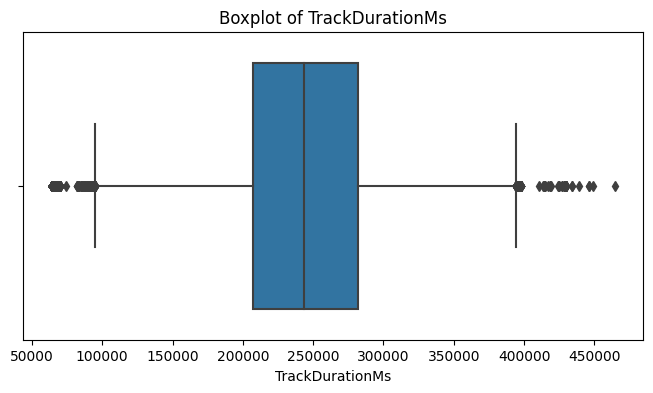

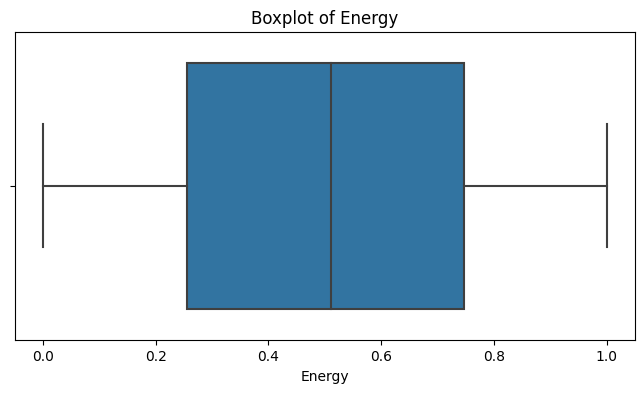

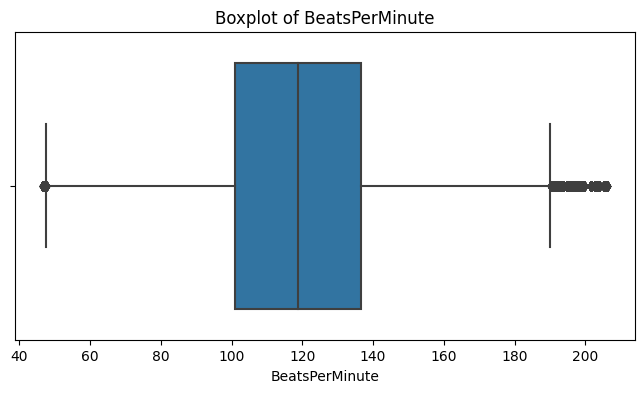

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in train.columns:
    # Check if column is numeric
    if train[col].dtype in ['int64', 'float64']:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=train, x=col)
        plt.title(f'Boxplot of {col}')
        plt.show()

In [9]:
train.columns

Index(['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality',
       'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore',
       'TrackDurationMs', 'Energy', 'BeatsPerMinute'],
      dtype='object')

<Axes: >

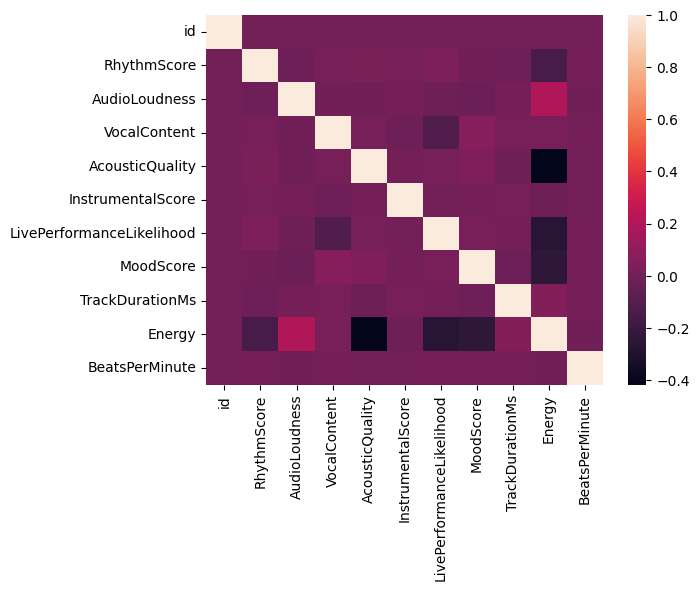

In [10]:


train.corr()
sns.heatmap(train.corr())

In [11]:
!pip install autogluon.tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.3/487.3 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 89.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from autogluon.core import TabularDataset

X_train, X_val = train_test_split(train, test_size=0.2, random_state=42)

X_train['ScaledTrackDurationMs'] = (X_train['TrackDurationMs'] - X_train['TrackDurationMs'].mean()) / X_train['TrackDurationMs'].std()
X_train.drop('TrackDurationMs', axis=1)
X_val['ScaledTrackDurationMs'] = (X_val['TrackDurationMs'] - X_val['TrackDurationMs'].mean()) / X_val['TrackDurationMs'].std()
X_val.drop('TrackDurationMs', axis=1)

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,Energy,BeatsPerMinute,ScaledTrackDurationMs
33141,33141,0.451778,-13.906602,0.023500,0.256488,0.054365,0.351738,0.655023,0.236533,65.19365,-0.543609
78954,78954,0.646031,-7.996873,0.143889,0.000005,0.000001,0.058229,0.396523,0.712800,87.33085,-0.412586
162663,162663,0.766942,-5.010941,0.158711,0.000005,0.000001,0.185612,0.371289,0.311400,88.85002,-0.705119
243122,243122,0.452465,-2.627512,0.076202,0.513895,0.428713,0.144865,0.492793,0.953333,159.29379,1.767181
278030,278030,0.710611,-8.960601,0.023500,0.267989,0.084244,0.334531,0.828207,0.276200,143.66694,1.516890
...,...,...,...,...,...,...,...,...,...,...,...
490497,490497,0.641498,-11.053389,0.094665,0.735356,0.000001,0.350138,0.582481,0.005867,125.75619,-2.357134
1772,1772,0.838005,-2.880091,0.120350,0.246801,0.000001,0.278027,0.671080,0.290467,142.94391,0.048011
269444,269444,0.711387,-8.907943,0.070076,0.165030,0.032839,0.024300,0.716263,0.391600,100.04995,-0.151532
324895,324895,0.318021,-9.274315,0.073088,0.567178,0.000001,0.024300,0.854191,0.986600,118.65849,0.791235


In [13]:
def bin_column(df, column, bins, bin_names=None):
    if bin_names is None:
        bin_names = [f'{b:.1f}_to_{b_next:.1f}' for b, b_next in zip(bins[:-1], bins[1:])]
    df[column + '_binned'] = pd.cut(df[column], bins=bins, labels=bin_names, include_lowest=True)
    return df

bins = [0.025, 0.1, 0.15, 0.2]
train = bin_column(train, 'VocalContent', bins)
test = bin_column(test, 'VocalContent', bins)

bins = [0.01, 0.2, 0.4, 0.6, 0.8, 1.0]
train = bin_column(train, 'AcousticQuality', bins)
test = bin_column(test, 'AcousticQuality', bins)

bins = [0.001, 0.2, 0.4, 0.6, 0.8, 1.0]
train = bin_column(train, 'InstrumentalScore', bins)
test = bin_column(test, 'InstrumentalScore', bins)

bins = [0.05, 0.2, 0.4]
train = bin_column(train, 'LivePerformanceLikelihood', bins)
test = bin_column(test, 'LivePerformanceLikelihood', bins)


bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
X_train = bin_column(X_train, 'MoodScore', bins)
X_val = bin_column(X_val, 'MoodScore', bins)

In [14]:
numerical_features = ['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality',
       'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore',
       'ScaledTrackDurationMs', 'Energy']

def add_feature_cross_terms(df, numerical_features):
    df_new = df.copy()
    # df['TrackDurationMin'] = df['TrackDurationMs'] / 60000 
    for i in range(len(numerical_features)):
        for j in range(i + 1, len(numerical_features)):  
            feature1 = numerical_features[i]
            feature2 = numerical_features[j]
            cross_term_name = f"{feature1}_x_{feature2}"
            df_new[cross_term_name] = df_new[feature1] * df_new[feature2]
    
    df_new['acoustic_instrumental_ratio'] = df_new['AcousticQuality'] / (df_new['InstrumentalScore'] + 1e-6)
    df_new['RhythmEnergyRatio'] = df_new['RhythmScore'] / (df_new['Energy'] + 1e-8)
    df_new['VocalInstrumentalRatio'] = df_new['VocalContent'] / (df_new['InstrumentalScore'] + 1e-8)
    df['EnergyBin'] = pd.cut(df['Energy'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    df['RhythmBin'] = pd.cut(df['RhythmScore'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    
    return df_new

X_train = add_feature_cross_terms(X_train, numerical_features)
X_val = add_feature_cross_terms(X_val, numerical_features)

In [15]:
X_train = TabularDataset(X_train)
X_val = TabularDataset(X_val)

In [16]:
def add_feature_sq_terms(df, numerical_features):
    for feature in numerical_features:
        df[f'{feature}_squared'] = df[feature] ** 2
        df[f'{feature}_sqrt'] = np.sqrt(np.abs(df[feature]))
    return df
    
# train = add_feature_sq_terms(train, numerical_features)
# test = add_feature_sq_terms(test, numerical_features)

In [17]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(label='BeatsPerMinute', problem_type='regression', eval_metric='root_mean_squared_error', path='/kaggle/working/predictor').fit(X_train, presets='best_quality')

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Nov 10 10:07:59 UTC 2024
CPU Count:          4
Memory Avail:       29.94 GB / 31.35 GB (95.5%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the da

In [18]:
predictor.leaderboard(X_val)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,CatBoost_BAG_L2,-26.437771,-26.463715,root_mean_squared_error,18.329684,36.015742,1632.690001,0.305399,0.179433,116.706254,2,True,9
1,WeightedEnsemble_L3,-26.438239,-26.461443,root_mean_squared_error,24.426798,53.521944,2062.374926,0.005337,0.008023,0.592265,3,True,11
2,LightGBM_BAG_L2,-26.438248,-26.463559,root_mean_squared_error,19.215177,36.358497,1559.955886,1.190892,0.522188,43.972140,2,True,8
3,LightGBMXT_BAG_L2,-26.438281,-26.463457,root_mean_squared_error,20.361729,36.979870,1573.118381,2.337444,1.143561,57.134634,2,True,7
4,LightGBM_BAG_L1,-26.438877,-26.464622,root_mean_squared_error,1.376979,0.697639,45.869676,1.376979,0.697639,45.869676,1,True,2
5,WeightedEnsemble_L2,-26.438971,-26.463917,root_mean_squared_error,1.694516,0.888064,208.938017,0.003367,0.008309,0.402026,2,True,6
6,CatBoost_BAG_L1,-26.439895,-26.465184,root_mean_squared_error,0.314170,0.182116,162.666315,0.314170,0.182116,162.666315,1,True,3
7,LightGBMXT_BAG_L1,-26.441657,-26.468314,root_mean_squared_error,2.264020,1.135018,53.444241,2.264020,1.135018,53.444241,1,True,1
8,NeuralNetFastAI_BAG_L1,-26.442636,-26.471470,root_mean_squared_error,8.247416,4.177315,530.873549,8.247416,4.177315,530.873549,1,True,5
9,ExtraTreesMSE_BAG_L2,-26.476501,-26.533506,root_mean_squared_error,20.893125,51.848172,1960.675887,2.868840,16.011863,444.692141,2,True,10


In [19]:
predictor.feature_importance(X_val)

Computing feature importance via permutation shuffling for 51 features using 5000 rows with 5 shuffle sets...
	971.95s	= Expected runtime (194.39s per shuffle set)
	301.87s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
MoodScore,0.014114,0.005202,0.001863,5,0.024824,0.003404
RhythmScore_x_MoodScore,0.004039,0.004995,0.072448,5,0.014323,-0.006246
RhythmScore_x_LivePerformanceLikelihood,0.002529,0.001781,0.016838,5,0.006196,-0.001138
RhythmScore_x_VocalContent,0.001924,0.001066,0.007828,5,0.004119,-0.000271
RhythmScore_x_ScaledTrackDurationMs,0.001753,0.001884,0.052961,5,0.005632,-0.002126
ScaledTrackDurationMs_x_Energy,0.001716,0.002342,0.088320,5,0.006539,-0.003106
MoodScore_binned,0.001625,0.001904,0.064476,5,0.005546,-0.002295
AudioLoudness_x_ScaledTrackDurationMs,0.001602,0.001594,0.043964,5,0.004885,-0.001681
AudioLoudness_x_Energy,0.001534,0.000637,0.002880,5,0.002846,0.000222
AcousticQuality_x_InstrumentalScore,0.001494,0.000770,0.006124,5,0.003079,-0.000091


In [20]:
test['ScaledTrackDurationMs'] = (test['TrackDurationMs'] - test['TrackDurationMs'].mean()) / test['TrackDurationMs'].std()
test.drop('TrackDurationMs', axis=1)


bins = [0.025, 0.1, 0.15, 0.2]
test = bin_column(test, 'VocalContent', bins)

bins = [0.01, 0.2, 0.4, 0.6, 0.8, 1.0]
test = bin_column(test, 'AcousticQuality', bins)

bins = [0.001, 0.2, 0.4, 0.6, 0.8, 1.0]
test = bin_column(test, 'InstrumentalScore', bins)

bins = [0.05, 0.2, 0.4]
test = bin_column(test, 'LivePerformanceLikelihood', bins)


bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
test = bin_column(test, 'MoodScore', bins)

test = add_feature_cross_terms(test, numerical_features)

test = TabularDataset(test)

In [21]:
y_pred = predictor.predict(test)

In [22]:
#!pip install autogluon.tabular[mitra]

In [23]:
submission = pd.DataFrame({'id' : test['id'], 'BeatsPerMinute' : y_pred})
submission.to_csv('/kaggle/working/submission.csv', index=False)